## 1. 호텔 예약 수요 데이터셋
호텔 예약 수요 데이터셋은 일반적으로 호텔 예약에 대한 수요 패턴을 분석하기 위한 데이터셋입니다. 이 데이터셋은 예약 취소, 체크인 날짜, 고객 유형, 체류 기간, 객실 유형, 예약 경로 등 다양한 요소를 포함하며, 주로 예약 트렌드 분석, 고객 행동 예측, 수요 예측 등에 사용됩니다.

# **2. 데이터셋 컬럼 설명**

- hotel: 호텔 유형 (Resort Hotel, City Hotel)
- is_canceled: 예약 취소 여부 (0: 예약 유지, 1: 예약 취소)
- lead_time: 예약과 실제 체크인 사이의 기간(일 단위)
- arrival_date_year: 도착 연도
- arrival_date_month: 도착 월
- arrival_date_week_number: 해당 연도의 주
- arrival_date_day_of_month: 도착 일
- stays_in_weekend_nights: 주말(토, 일) 동안의 숙박일 수
- stays_in_week_nights: 주중(월~금) 동안의 숙박일 수
- adults: 성인 투숙객 수
- children: 어린이 투숙객 수
- babies: 유아 투숙객 수
- meal: 예약된 식사 유형
- country: 고객의 국가
- market_segment: 예약 시장 세그먼트
- distribution_channel: 예약 채널 (예: 온라인, 오프라인)
- is_repeated_guest: 재방문 여부
- previous_cancellations: 이전 예약 취소 횟수
- reserved_room_type: 예약된 객실 유형
- assigned_room_type: 실제 배정된 객실 유형
- booking_changes: 예약 변경 횟수
- deposit_type: 보증금 유형 (No Deposit, Non Refund, Refundable)
- days_in_waiting_list: 대기자 명단에 있었던 일 수
- customer_type: 고객 유형 (예: Transient, Group)
- adr: 평균 일일 요금 (유로)
- required_car_parking_spaces: 주차 공간 요구 수
- total_of_special_requests: 특별 요청 수
- reservation_status: 예약 상태 (Check-Out, Canceled, No-Show)
- reservation_status_date: 예약 상태가 마지막으로 업데이트된 날짜
# **3. 기본 정보 확인**

In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

hotel_raw = pd.read_csv('./hotel_bookings.csv')
hotel_raw

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [65]:
hotel_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [66]:
hotel_raw.isna().sum()[hotel_raw.isna().sum() > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [67]:
hotel_raw.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [68]:
hotel_raw.describe(include='str').T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


In [69]:
print("행/렬 크기:", hotel_raw.shape)
print("타깃 분포")
print(hotel_raw['is_canceled'].value_counts())
print("타깃 비율")
print(hotel_raw['is_canceled'].value_counts(normalize=True).round(2))

행/렬 크기: (119390, 32)
타깃 분포
is_canceled
0    75166
1    44224
Name: count, dtype: int64
타깃 비율
is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64


# EDA

In [70]:
missing_sumary = pd.DataFrame({
    "missing_count": hotel_raw.isna().sum(),
    "missing_ratio": hotel_raw.isna().mean(),
}).sort_values("missing_count", ascending=False)
missing_sumary[missing_sumary['missing_count'] > 0].T

,company,agent,country,children
missing_count,112593.000000,16340.000000,488.000000,4.000000
missing_ratio,0.943069,0.136862,0.004087,0.000034


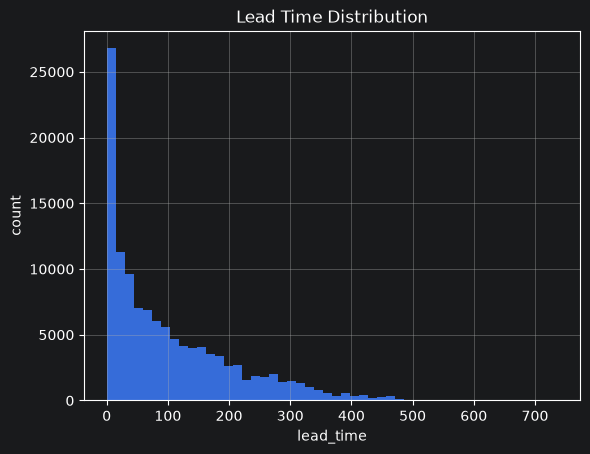

In [71]:
# 최소값부터 최대값까지를 50개의 구간으로 나눈 다음, 각 구간에 데이터가 몇개 들어있는지 막대로 확인
hotel_raw['lead_time'].hist(bins=50)
plt.title("Lead Time Distribution")
plt.xlabel("lead_time")
plt.ylabel("count")
plt.show()

In [72]:
print(hotel_raw['lead_time'].max())

737


In [73]:
print(hotel_raw['hotel'].unique())

<StringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str


In [74]:
cancel_by_hotel = hotel_raw.groupby("hotel")['is_canceled'].mean().sort_values(ascending=False)
cancel_by_hotel

hotel
City Hotel      0.417270
Resort Hotel    0.277634
Name: is_canceled, dtype: float64

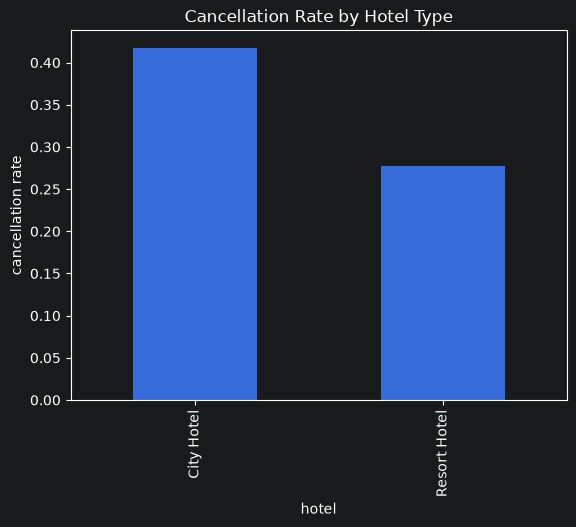

In [75]:
cancel_by_hotel.plot(kind="bar")
plt.title("Cancellation Rate by Hotel Type")
plt.ylabel('cancellation rate')
plt.show()

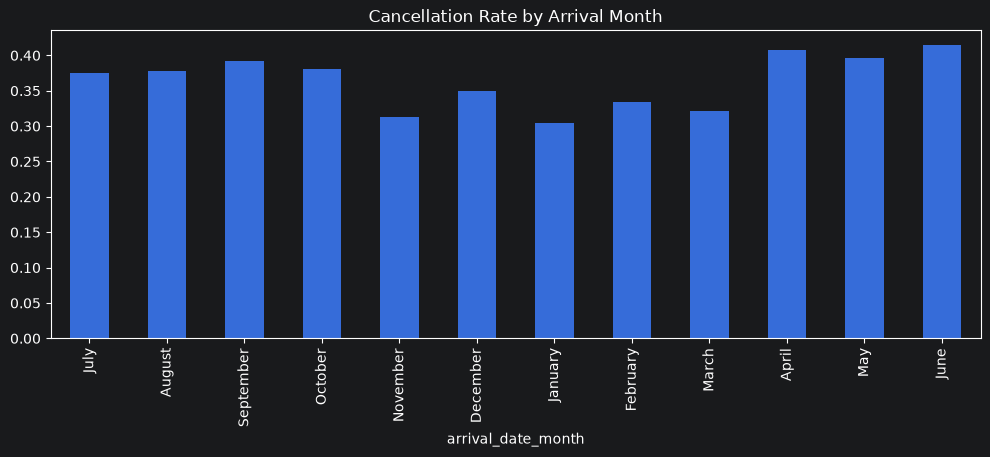

In [76]:
month_order = list(hotel_raw['arrival_date_month'].unique())
month_order

cancel_by_month = hotel_raw.groupby("arrival_date_month")['is_canceled'].mean().reindex(month_order)
cancel_by_month.plot(kind="bar", figsize=(12, 4))
plt.title("Cancellation Rate by Arrival Month")
plt.show()

In [77]:
# def add_basic_features(df):
#     df = df.copy()
#     df['children'] = df['children'].fillna(0)
#     df['people'] = df['adults'] + df['children'] + df['babies']
#
#     df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
#     season_map = {
#         'December': 'winter', 'January': 'winter', 'February': 'winter',
#         'March': 'spring', 'April': 'spring', 'May': 'spring',
#         'June': 'summer', 'July': 'summer', 'August': 'summer',
#         'September': 'fall', 'October': 'fall', 'November': 'fall',
#     }
#     df['season'] = df['arrival_date_month'].map(season_map)
#
#     previous_total = df['previous_cancellations'] + df['previous_bookings_not_canceled']
#     # 이전 취소율: 분모가 0보다 크면 캔슬수 / 전체, 기록이 없으면 -1 처리
#     df['previout_cancel_rate'] = np.where(
#         previous_total > 0, df['previous_cancellations'] / previous_total, -1
#     )
#     return df
def add_basic_features(df):
    df = df.copy()
    df['children'] = df['children'].fillna(0)
    df['people'] = df['adults'] + df['children'] + df['babies'] # 인원수
    df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

    season_map = {
        'December': 'winter', 'January': 'winter', 'February': 'winter',
        'March': 'spring', 'April': 'spring', 'May': 'spring',
        'June': 'summer', 'July': 'summer', 'August': 'summer',
        'September': 'fall', 'October': 'fall', 'November': 'fall',
    }
    df['season'] = df['arrival_date_month'].map(season_map)
    previous_total = df['previous_cancellations'] + df['previous_bookings_not_canceled']
    # 이전 취소율: 분모가 0보다 크면 캔슬수 / 전체, 기록이 없으면 -1 처리
    df['previous_cancel_rate'] = np.where(
        previous_total > 0, df['previous_cancellations'] / previous_total, -1)

    return df

In [78]:
hotel = add_basic_features(hotel_df)
hotel

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,people,total_nights,season,previous_cancel_rate
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,2.0,0,summer,-1.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,2.0,0,summer,-1.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,1.0,1,summer,-1.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,1.0,1,summer,-1.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,2015-07-03,2.0,2,summer,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,Transient,96.14,0,0,Check-Out,2017-09-06,2.0,7,summer,-1.0
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,Transient,225.43,0,2,Check-Out,2017-09-07,3.0,7,summer,-1.0
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,Transient,157.71,0,4,Check-Out,2017-09-07,2.0,7,summer,-1.0
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,Transient,104.40,0,0,Check-Out,2017-09-07,2.0,7,summer,-1.0


In [79]:
# people이 0인 데이터는 비정상 데이터로 제거
hotel = hotel[hotel['people'] > 0].copy()

In [80]:
# 실제 예약 시점 예측에 부적절하거나 누수 위험이 큰 컬럼 제거
leakage_or_post_booking_cols = [
    'reservation_status', 'reservation_status_date', 'assigned_room_type'
]

redundant_cols = [
    'adults', 'children', 'babies', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'arrival_date_month', 'previous_cancellations', 'previous_bookings_not_canceled'
]

cols_to_drop = [col for col in leakage_or_post_booking_cols + redundant_cols if col in hotel.columns]
hotel = hotel.drop(columns=cols_to_drop)
hotel.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,meal,country,market_segment,distribution_channel,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,people,total_nights,season,previous_cancel_rate
0,Resort Hotel,0,342,2015,27,1,BB,PRT,Direct,Direct,...,NaN,0,Transient,0.0,0,0,2.0,0,summer,-1.0
1,Resort Hotel,0,737,2015,27,1,BB,PRT,Direct,Direct,...,NaN,0,Transient,0.0,0,0,2.0,0,summer,-1.0
2,Resort Hotel,0,7,2015,27,1,BB,GBR,Direct,Direct,...,NaN,0,Transient,75.0,0,0,1.0,1,summer,-1.0
3,Resort Hotel,0,13,2015,27,1,BB,GBR,Corporate,Corporate,...,NaN,0,Transient,75.0,0,0,1.0,1,summer,-1.0
4,Resort Hotel,0,14,2015,27,1,BB,GBR,Online TA,TA/TO,...,NaN,0,Transient,98.0,0,1,2.0,2,summer,-1.0


In [81]:
hotel = hotel.drop(columns=cols_to_drop)
hotel.head()

KeyError: "['reservation_status', 'reservation_status_date', 'assigned_room_type', 'adults', 'children', 'babies', 'stays_in_weekend_nights', 'stays_in_week_nights', 'arrival_date_month', 'previous_cancellations', 'previous_bookings_not_canceled'] not found in axis"

In [ ]:
hotel.info()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = hotel.drop(columns='is_canceled')
y = hotel['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=2026,
    stratify=y
)

In [ ]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

In [ ]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
print("숫자형 컬럼 수:", len(numeric_features))
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()
print("범주형 컬럼 수:", len(categorical_features))
print(categorical_features)